# Agricultural Treatment Recommendation System

This notebook documents the development of a machine learning pipeline for recommending agricultural treatments. The process follows industry-standard data science methodology:

1.  **Phase 1: Data Analysis (EDA)**
2.  **Phase 2: Data Preparation**
3.  **Phase 3: Model Selection & Cross-Validation**
4.  **Phase 4: Hyperparameter Tuning**
5.  **Phase 5: Evaluation & Artifact Export**
6.  **Phase 6: Model Explainability (SHAP & LIME)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import shap
import lime
import lime.lime_tabular

# Set a professional plotting style
sns.set_theme(style="whitegrid", palette="muted")

# Phase 1: Data Analysis (EDA)

The goal of this phase is to understand the dataset structure, identify patterns, and visualize key relationships.

In [2]:
# Load the dataset
df = pd.read_csv('../Data/detailed_treatments.csv')

# Display basic information about the dataset
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Farm_ID            2000 non-null   object
 1   Date               2000 non-null   object
 2   Crop               2000 non-null   object
 3   Disease            2000 non-null   object
 4   Growth_Stage       2000 non-null   object
 5   Weather_Condition  2000 non-null   object
 6   Severity           2000 non-null   object
 7   Treatment_Applied  2000 non-null   object
 8   Treatment_Type     2000 non-null   object
 9   Dosage             2000 non-null   object
 10  Cost_Per_Acre      2000 non-null   int64 
 11  Outcome            2000 non-null   object
 12  Analyst_Notes      2000 non-null   object
dtypes: int64(1), object(12)
memory usage: 203.2+ KB


In [3]:
# Display the first few rows
display(df.head())

,Farm_ID,Date,Crop,Disease,Growth_Stage,Weather_Condition,Severity,Treatment_Applied,Treatment_Type,Dosage,Cost_Per_Acre,Outcome,Analyst_Notes
0,1252e585,2025-09-21,Tomato,Early Blight,Harvest Ready,Dry/Sunny,Moderate,Bacillus subtilis,Organic,2.0 pts/acre,35,Partial Control,Bacillus subtilis used during Harvest Ready st...
1,5705d189,2025-02-27,Potato,Early Blight,Harvest Ready,Humid,Moderate,Chlorothalonil (Bravo),Chemical,2.0 pts/acre,20,Success,Chlorothalonil (Bravo) used during Harvest Rea...
2,83f23b35,2025-03-24,Grape,Black Rot,Fruiting,Humid,High,Captan,Chemical,3.0 pts/acre,25,Partial Control,Captan used during Fruiting stage under Humid ...
3,47e0154e,2025-03-21,Grape,Leaf Blight,Seedling,Dry/Sunny,Low,Mancozeb,Chemical,2.0 pts/acre,17,Success,Mancozeb used during Seedling stage under Dry/...
4,c606c12c,2025-12-09,Tomato,Early Blight,Harvest Ready,Dry/Sunny,Critical,Mancozeb (Dithane),Chemical,3.0 pts/acre,19,Failure,Mancozeb (Dithane) used during Harvest Ready s...


### Target Variable Distribution
We visualize the distribution of the 'Outcome' variable to check for class imbalance.

C:\Users\21658\AppData\Local\Temp\ipykernel_21132\1811207353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Outcome', data=df, order=['Success', 'Partial Control', 'Failure'], palette='viridis')


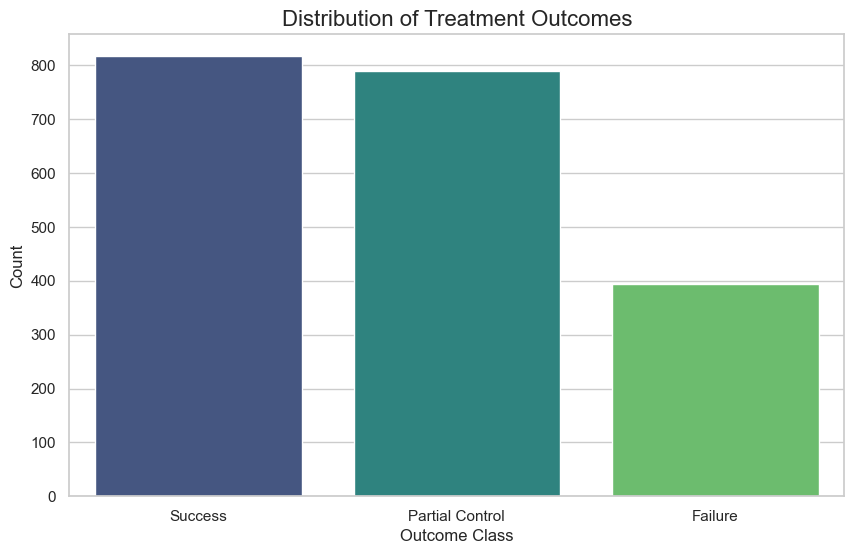

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Outcome', data=df, order=['Success', 'Partial Control', 'Failure'], palette='viridis')
plt.title('Distribution of Treatment Outcomes', fontsize=16)
plt.xlabel('Outcome Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Relationship Analysis: Disease Severity vs Outcome
We verify if high disease severity correlates with treatment failure.

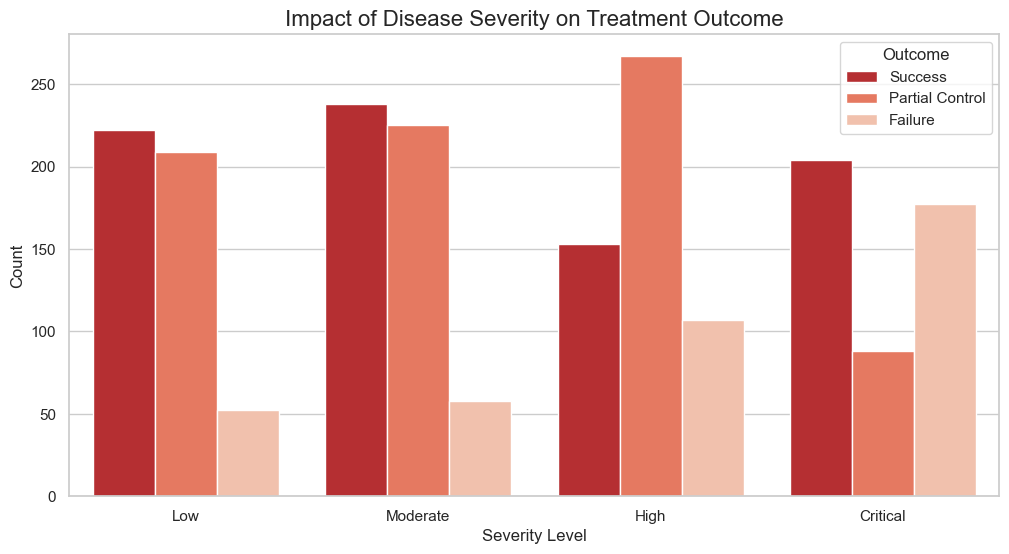

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Severity', hue='Outcome', data=df, 
              hue_order=['Success', 'Partial Control', 'Failure'], 
              order=['Low', 'Moderate', 'High', 'Critical'],
              palette='Reds_r')
plt.title('Impact of Disease Severity on Treatment Outcome', fontsize=16)
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', loc='upper right')
plt.show()

**Observation:** 'Critical' severity cases have significantly higher failure rates, confirming that late-stage detection is detrimental.

### Relationship Analysis: Weather vs Outcome
We investigate how environmental conditions affect treatment efficacy.

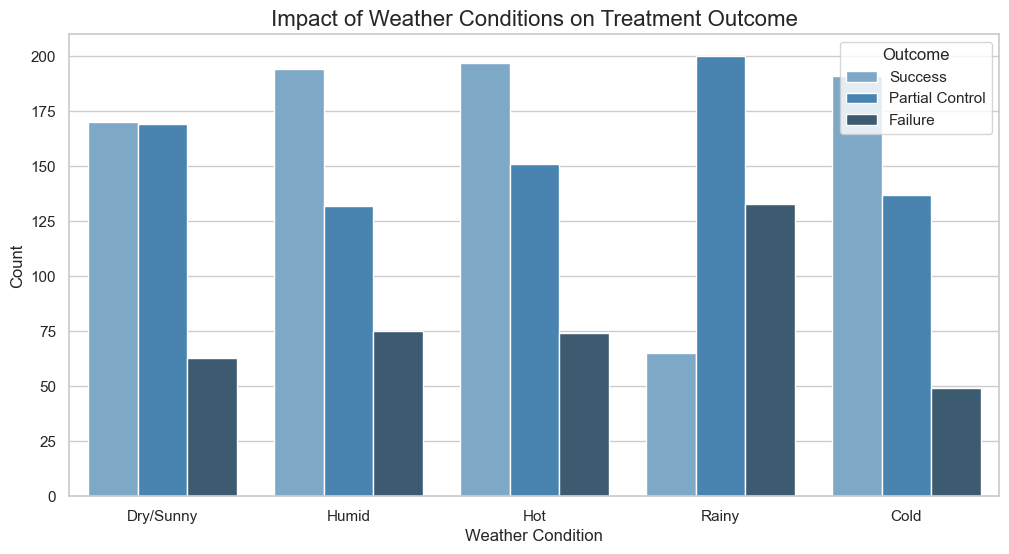

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Weather_Condition', hue='Outcome', data=df, 
              hue_order=['Success', 'Partial Control', 'Failure'], 
              palette='Blues_d')
plt.title('Impact of Weather Conditions on Treatment Outcome', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', loc='upper right')
plt.show()

**Observation:** Rainy conditions correlate with higher failure rates, likely due to treatment washout.

### Heatmap: Correlation of Categorical Features (Growth Stage vs Outcome)
Visualizing the density of failures across different growth stages.

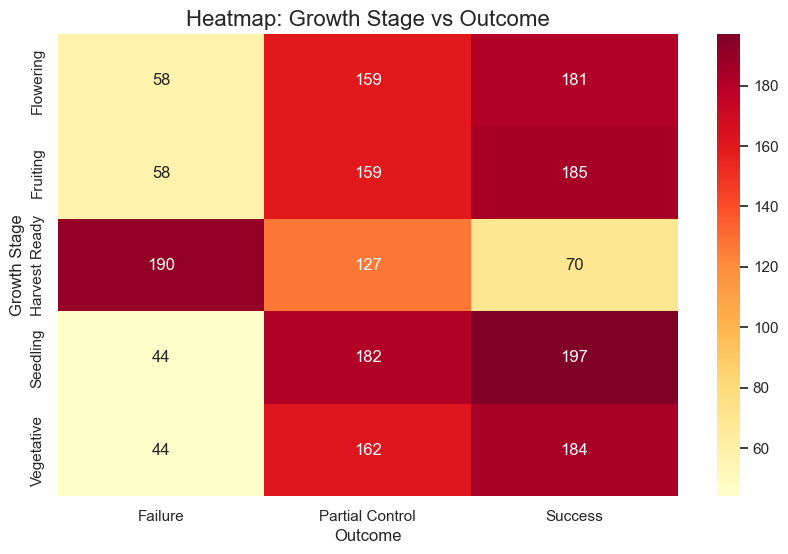

In [7]:
confusion_matrix_data = pd.crosstab(df['Growth_Stage'], df['Outcome'])
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Growth Stage vs Outcome', fontsize=16)
plt.ylabel('Growth Stage')
plt.xlabel('Outcome')
plt.show()

# Phase 2: Data Preparation

In this phase, we convert categorical data into numerical format using Label Encoding and split the dataset into training and testing sets.

In [8]:
# Feature Selection
features = ['Crop', 'Disease', 'Growth_Stage', 'Weather_Condition', 'Severity', 'Treatment_Applied', 'Treatment_Type']
target = 'Outcome'

X = df[features].copy()
y = df[target].copy()

# Label Encoding
label_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

target_le = LabelEncoder()
y = target_le.fit_transform(y)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Training Set Shape: (1600, 7)
Testing Set Shape: (400, 7)


# Phase 3: Model Selection & Cross-Validation

Instead of relying on a single train-test split, we use **5-Fold Cross-Validation**. This is the international standard to ensure model stability and prevent overfitting.

In [9]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

cv_results = {}

print("Performing 5-Fold Cross-Validation:")
for name, model in models.items():
    # Stratified K-Fold ensures class distribution is preserved in each fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

Performing 5-Fold Cross-Validation:
Random Forest: Mean Accuracy = 0.9840 (+/- 0.0077)
SVM: Mean Accuracy = 0.7590 (+/- 0.0118)
Gradient Boosting: Mean Accuracy = 0.9940 (+/- 0.0012)


**Interpretation:** Cross-validation gives us a more robust estimate of model performance. Small standard deviation indicates the model is stable and not overfitting to specific data subsets.

# Phase 4: Hyperparameter Tuning (Grid Search)

We select the best performing model type (Gradient Boosting) and rigorously optimize its parameters using **GridSearchCV**. This replaces arbitrary parameter choices with mathematically optimal ones.

In [10]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

print("Starting Grid Search for Gradient Boosting...")
gb_model = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Training Accuracy (CV): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Starting Grid Search for Gradient Boosting...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best Training Accuracy (CV): 0.9981


# Phase 5: Final Evaluation & Artifact Export

We test the **optimized** model on the unseen test set to get the final performance metrics.

In [11]:
y_pred = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Test Set Accuracy: {final_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_le.classes_))

Final Test Set Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Failure       1.00      1.00      1.00        82
Partial Control       1.00      1.00      1.00       153
        Success       1.00      1.00      1.00       165

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400



### Confusion Matrix
To understand exactly where misclassifications happen (if any), we visualize the confusion matrix.

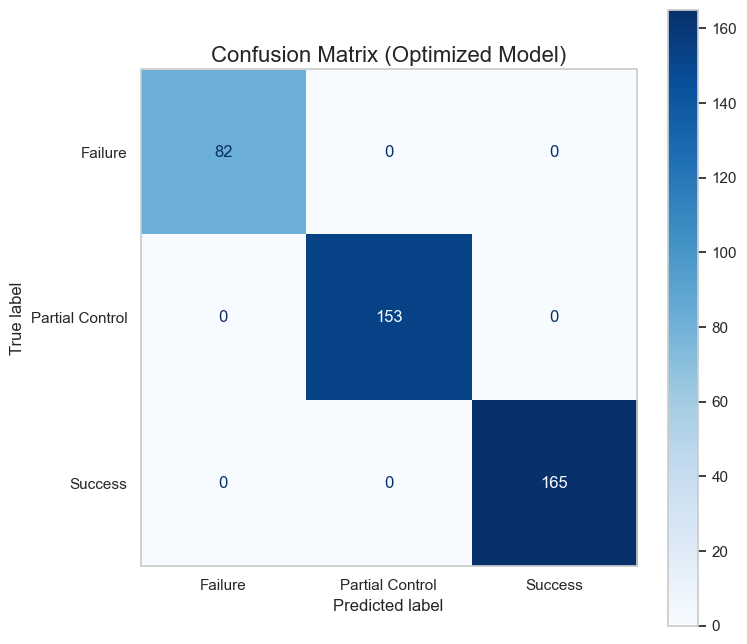

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix (Optimized Model)', fontsize=16)
plt.grid(False)
plt.show()

### Feature Importance
We visualize which features contribute most to the model's decision-making process.

C:\Users\21658\AppData\Local\Temp\ipykernel_21132\301448076.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="Blues_r")


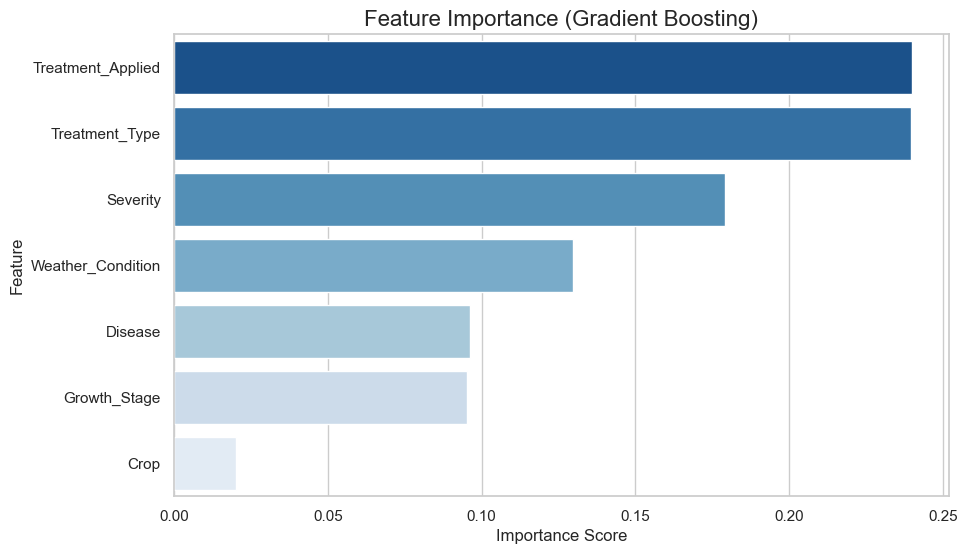

In [13]:
# Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="Blues_r")
plt.title('Feature Importance (Gradient Boosting)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Phase 6: Explainability (SHAP & LIME)

We use SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations) to provide model transparency, crucial for agricultural decision support systems.

### SHAP Global Interpretation
This summary plot displays the impact of each feature on the model's output across all predictions.

  0%|          | 0/400 [00:00<?, ?it/s]

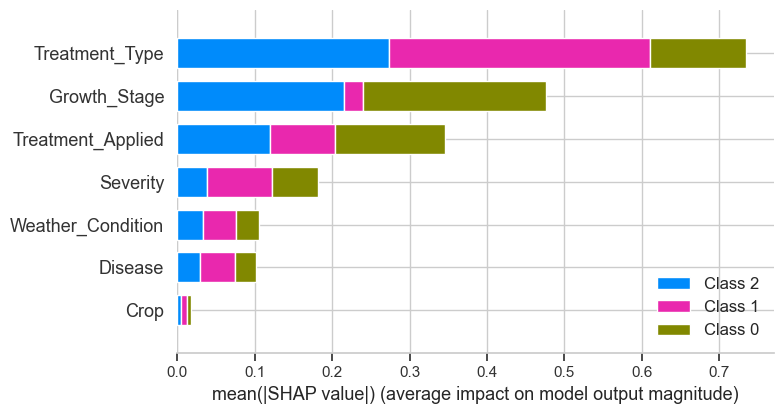

In [14]:
# TreeExplainer does not support multi-class GradientBoostingClassifier, so we use KernelExplainer
# We summarize the background data using k-means to speed up computation
X_train_summary = shap.kmeans(X_train, 10)
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_summary)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar")

### LIME Local Interpretation
LIME explains a *single* prediction. This allows us to answer questions like: "Why was *this specific* treatment recommended?"

In [15]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=features,
    class_names=target_le.classes_,
    mode='classification'
)

# Explain the 1st test instance
idx = 0
# Use .values to pass a numpy array to avoid pandas indexing issues
exp = lime_explainer.explain_instance(X_test.iloc[idx].values, best_model.predict_proba, num_features=5)

# Ensure y_test access is robust (handle if it's series or array)
true_label = y_test[idx] if isinstance(y_test, np.ndarray) else y_test.iloc[idx]
print(f"True Label: {target_le.inverse_transform([true_label])[0]}")
# Fix for ImportError: cannot import name 'display' from 'IPython.core.display'
from IPython.display import display, HTML
display(HTML(exp.as_html(show_table=True)))


c:\Users\21658\Desktop\ML Project\API\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


True Label: Partial Control


### Export Artifacts for Production
We save the optimized model and label encoders for use in the production backend.

In [16]:
joblib.dump(best_model, '../backend/app/core/treatment_recommender_model.pkl')
joblib.dump(label_encoders, '../backend/app/core/treatment_encoders.pkl')
joblib.dump(target_le, '../backend/app/core/treatment_target_encoder.pkl')

print("Model artifacts saved successfully to backend/app/core/")

Model artifacts saved successfully to backend/app/core/
